This is a trial run. I just want to define my main functions here (Gaussian elimination, random circuit generation and evolution, entropy calculation, etc.) and then test it on small systems. Then I will scale things up in another folder. 

2 separate functions for packing and rank calculations

#TWO SEPARATE FUNCTIONS FOR PACKING AND RANK CALCULATION, BOTH OPTIMIZED WITH NUMBA

import numpy as np
from numba import njit
import time

# --- 1. The Matrix Packer ---
@njit
def pack_binary_matrix(binary_matrix):
    """
    Compresses an (N x M) binary matrix into an (N x W) uint64 matrix.
    Every 64 columns of the original matrix become 1 column of 64-bit integers.
    """
    rows, cols = binary_matrix.shape
    # Calculate how many 64-bit words we need per row (ceiling division)
    words = (cols + 63) // 64 
    
    # Initialize the compressed matrix with 64-bit unsigned integers
    packed = np.zeros((rows, words), dtype=np.uint64)
    
    """Iterate through the original binary matrix and set the corresponding bits in the packed matrix. We do this by 
    calculating the word index and bit index for each 1 in the original matrix, then using bitwise OR with a bit mask to set the bit in the packed matrix.
    The bitmask is created by left-shifting 1 by the bit index by an amount equal to the bit index, and we ensure that the shift is done on a 64-bit type to prevent overflow.
    The bitmask is then ORed with the current value in the packed matrix at the appropriate word index to set the bit corresponding to the 1 in the original matrix.
    We only process the 1s to save time, as the 0s are already"""
    for r in range(rows):
        for c in range(cols):
            if binary_matrix[r, c] == 1: 
                word_idx = c // 64 #extract the word index
                bit_idx = c % 64 #extract the bit index within that word

                # Force the 1 to be a 64-bit type before shifting to prevent overflow. 
                bit_mask = np.uint64(1) << np.uint64(bit_idx)
                packed[r, word_idx] |= bit_mask #manually set the bit using bitwise OR for each 1 in the original matrix
                
    return packed

# --- 2. The Ultra-Fast Rank Solver ---
@njit
def gf2_rank(packed_matrix, num_cols):
    """
    Computes the GF(2) rank directly on the packed uint64 memory blocks.
    Utilizes the upper-triangular shortcut to cut mathematical operations in half.
    """
    mat = packed_matrix.copy()
    rows, words = mat.shape
    rank = 0
    
    for col in range(num_cols):
        # Locate the exact integer and the exact bit within it for the current column
        word_idx = col // 64
        bit_idx = col % 64
        
        # 1. Pivot search (Optimized: Only search from the current rank downwards)
        pivot_row = -1
        for r in range(rank, rows):
            # Shift the target bit to the 0th position and mask it with 1
            if (mat[r, word_idx] >> np.uint64(bit_idx)) & np.uint64(1):
                pivot_row = r
                break
                
        if pivot_row == -1:
            continue
            
        # 2. Row swap
        if pivot_row != rank:
            for w in range(words):
                temp = mat[rank, w]
                mat[rank, w] = mat[pivot_row, w]
                mat[pivot_row, w] = temp
                
        # 3. Row elimination via XOR 
        # (Optimized: Only eliminate strictly BELOW the pivot to form Row Echelon Form)
        for r in range(rank + 1, rows):
            if (mat[r, word_idx] >> np.uint64(bit_idx)) & np.uint64(1):
                # The Hardware Magic: XORing a single word processes 64 bits simultaneously
                for w in range(words):
                    mat[r, w] ^= mat[rank, w]
                    
        rank += 1
        if rank == rows:
            break
            
    return rank

# ==========================================
# BENCHMARK TEST (10000 x 10000)
# ==========================================
if __name__ == "__main__":
    N = 10000
    print(f"Generating random {N} x {N} binary matrix...")
    # Use uint8 for the initial generation to save RAM before packing
    binary_matrix = np.random.randint(0, 2, (N, 2 * N), dtype=np.uint8)
    
    # Pack the matrix
    t0 = time.time()
    packed_mat = pack_binary_matrix(binary_matrix)
    rank = gf2_rank(packed_mat, num_cols=2 *N)
    t1 = time.time()
    
    print(f"Rank: {rank}")
    print(f"Rank calculation time: {t1 - t0:.4f} seconds.")

One single function for both packing and rank calculation, uses matrix packing and passes the output (packed matrix) to the rank calculator to calculate the rank. As of March 23, this is faster.

In [ ]:
#ONE SINGLE FUNCTION FOR BOTH PACKING AND RANK CALCULATION, OPTIMIZED WITH NUMBA. THIS DOES NOT PRESERVE THE ORIGINAL MATRIX!!!!!!!!!!!!!

import numpy as np
from numba import njit, test
import time

# --- 1. The Matrix Packer ---
@njit
def rank_binary_matrix(binary_matrix):
    """
    Compresses an (N x M) binary matrix into an (N x W) uint64 matrix.
    Every 64 columns of the original matrix become 1 column of 64-bit integers.
    """
    rows, cols = binary_matrix.shape
    # Calculate how many 64-bit words we need per row (ceiling division)
    words = (cols + 63) // 64 
    
    # Initialize the compressed matrix with 64-bit unsigned integers
    packed = np.zeros((rows, words), dtype=np.uint64)
    
    """Iterate through the original binary matrix and set the corresponding bits in the packed matrix. We do this by 
    calculating the word index and bit index for each 1 in the original matrix, then using bitwise OR with a bit mask to set the bit in the packed matrix.
    The bitmask is created by left-shifting 1 by the bit index by an amount equal to the bit index, and we ensure that the shift is done on a 64-bit type to prevent overflow.
    The bitmask is then ORed with the current value in the packed matrix at the appropriate word index to set the bit corresponding to the 1 in the original matrix.
    We only process the 1s to save time, as the 0s are already"""
    for r in range(rows):
        for c in range(cols):
            if binary_matrix[r, c] == 1: 
                word_idx = c // 64 #extract the word index
                bit_idx = c % 64 #extract the bit index within that word

                # Force the 1 to be a 64-bit type before shifting to prevent overflow. 
                bit_mask = np.uint64(1) << np.uint64(bit_idx)
                packed[r, word_idx] |= bit_mask #manually set the bit using bitwise OR for each 1 in the original matrix
                
    """
    Computes the GF(2) rank directly on the packed uint64 memory blocks.
    Utilizes the upper-triangular shortcut to cut mathematical operations in half.
    """
    rows, words = packed.shape
    rank = 0
    
    for col in range(cols):
        # Locate the exact integer and the exact bit within it for the current column
        word_idx = col // 64
        bit_idx = col % 64
        
        # 1. Pivot search (Optimized: Only search from the current rank downwards)
        pivot_row = -1
        for r in range(rank, rows):
            # Shift the target bit to the 0th position and mask it with 1
            if (packed[r, word_idx] >> np.uint64(bit_idx)) & np.uint64(1):
                pivot_row = r
                break
                
        if pivot_row == -1:
            continue
            
        # 2. Row swap
        if pivot_row != rank:
            for w in range(words):
                temp = packed[rank, w]
                packed[rank, w] = packed[pivot_row, w]
                packed[pivot_row, w] = temp
                
        # 3. Row elimination via XOR 
        # (Optimized: Only eliminate strictly BELOW the pivot to form Row Echelon Form)
        for r in range(rank + 1, rows):
            if (packed[r, word_idx] >> np.uint64(bit_idx)) & np.uint64(1):
                # The Hardware Magic: XORing a single word processes 64 bits simultaneously
                for w in range(words):
                    packed[r, w] ^= packed[rank, w]
                    
        rank += 1
        if rank == rows:
            break
            
    return rank

## ==========================================
# TESTING
## ==========================================
test1 = np.array([[1, 0],
                 [0, 1]])
print("\nTest Matrix 1:")
print(test1 )
print("Calculated Rank:", rank_binary_matrix(test1))

test2 = np.array([[1, 0, 1],
                 [0, 1, 1], 
                   [1, 1, 0]])
print("\nTest Matrix 2:")
print(test2 )
print("Calculated Rank:", rank_binary_matrix(test2))

test3 = np.array([[1, 0],
                 [1, 0], 
                [0, 0]])
print("\nTest Matrix 3:")
print(test3 )
print("Calculated Rank:", rank_binary_matrix(test3))

test4 = np.array([[1, 1, 0, 0],
                 [0, 1, 1, 0],
                 [0, 0, 1, 1],
                 [1, 0, 0, 1]])
print("\nTest Matrix 4:")
print(test4 )
print("Calculated Rank:", rank_binary_matrix(test4))

test5 = np.array([[1]])
print("\nTest Matrix 5:")
print(test5 )
print("Calculated Rank:", rank_binary_matrix(test5))

test6 = np.zeros((10, 10))
print("\nTest Matrix 6 (10x10 zeros):")
print(test6 )
print("Calculated Rank:", rank_binary_matrix(test6))

test7 = np.ones((7, 9))
print("\nTest Matrix 7 (7x9 ones):")
print(test7 )
print("Calculated Rank:", rank_binary_matrix(test7))
    




Test Matrix 1:
[[1 0]
 [0 1]]
Calculated Rank: 2

Test Matrix 2:
[[1 0 1]
 [0 1 1]
 [1 1 0]]
Calculated Rank: 2

Test Matrix 3:
[[1 0]
 [1 0]
 [0 0]]
Calculated Rank: 1

Test Matrix 4:
[[1 1 0 0]
 [0 1 1 0]
 [0 0 1 1]
 [1 0 0 1]]
Calculated Rank: 3

Test Matrix 5:
[[1]]
Calculated Rank: 1

Test Matrix 6 (10x10 zeros):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
Calculated Rank: 0

Test Matrix 7 (7x9 ones):
[[1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]]
Calculated Rank: 1


Entropy calculator (simple)

In [29]:
import numpy as np

def calculate_entropy(stabilizer, n_cut):
    """
    Calculates the entanglement entropy for a given stabilizer matrix and cut.
    """
    if n_cut > stabilizer.shape[0]:
        raise ValueError("n_cut cannot be greater than the number of qubits in the stabilizer.")
    L = stabilizer.shape[1] // 2
    #print(f"Stabilizer shape: {stabilizer.shape}, L: {L}, n_cut: {n_cut}")  
    
    # 1. Grab X columns for qubits 0 to n-1
    # 2. Grab Z columns for qubits 0 to n-1 (offset by L)
    # We use np.hstack to join them into an L x 2n matrix
    sub_A = np.hstack([stabilizer[:, :n_cut], stabilizer[:, L : L+n_cut]])
    #print(f"Submatrix: \n {sub_A} \n")

    rank = rank_binary_matrix(sub_A)
    #print(f"Rank: {rank}")

    return rank - n_cut



Test of the entropy calculation follow. 

We first have the Bell state

In [30]:
import numpy as np
from numba import njit
import stim


# 1. Create the 'Instruction' set
circuit = stim.Circuit()
circuit.append("H", [0])
circuit.append("CNOT", [0, 1])
circuit.append("M", [0])


# 2. Create the 'Simulator' (The thing that holds the state)
sim = stim.TableauSimulator()

# 3. Feed the instructions to the simulator
sim.do(circuit)
hasattr(sim, "current_tableau")
# 4. Peek at the Binary Check Matrix (Tableau)
# We use current_inverse_tableau because it gives the 'stabilizers' directly
# Pull the internal Heisenberg state and invert it to get the Schrödinger state
tableau = sim.current_inverse_tableau() ** -1

# 1. to_numpy() returns 6 blocks: 
# (X-to-X, X-to-Z, Z-to-X, Z-to-Z, x_signs, z_signs)
x2x, x2z, z2x, z2z, x_signs, z_signs = tableau.to_numpy()

# 2. Extract the Stabilizers (Z-generators). 
# We horizontally stack the X-components and Z-components.
stabilizer_matrix = np.hstack([z2x, z2z])

# Convert boolean (True/False) to integers (1/0) for your GF(2) solver
stabilizer_matrix = stabilizer_matrix.astype(int)
print(f"Stabilizer Matrix:\n{stabilizer_matrix} \n")

eigenvalues = np.where(z_signs, -1, 1)

print(f"Stabilizer Eigenvalues: {eigenvalues}")

print(f"Entanglement Entropy: {calculate_entropy(stabilizer_matrix, n_cut=1)}")


Stabilizer Matrix:
[[0 0 1 0]
 [0 0 1 1]] 

Stabilizer Eigenvalues: [-1  1]
Entanglement Entropy: 0


Bell state with measurement below

In [31]:
import numpy as np
from numba import njit
import stim


# 1. Create the 'Instruction' set
circuit = stim.Circuit()
circuit.append("H", [0])
circuit.append("CNOT", [0, 1])
circuit.append("M", [0])


# 2. Create the 'Simulator' (The thing that holds the state)
sim = stim.TableauSimulator()

# 3. Feed the instructions to the simulator
sim.do(circuit)
hasattr(sim, "current_tableau")
# 4. Peek at the Binary Check Matrix (Tableau)
# We use current_inverse_tableau because it gives the 'stabilizers' directly
# Pull the internal Heisenberg state and invert it to get the Schrödinger state
tableau = sim.current_inverse_tableau() ** -1

# 1. to_numpy() returns 6 blocks: 
# (X-to-X, X-to-Z, Z-to-X, Z-to-Z, x_signs, z_signs)
x2x, x2z, z2x, z2z, x_signs, z_signs = tableau.to_numpy()

# 2. Extract the Stabilizers (Z-generators). 
# We horizontally stack the X-components and Z-components.
stabilizer_matrix = np.hstack([z2x, z2z])

# Convert boolean (True/False) to integers (1/0) for your GF(2) solver
stabilizer_matrix = stabilizer_matrix.astype(int)
print(f"Stabilizer Matrix:\n{stabilizer_matrix} \n")

eigenvalues = np.where(z_signs, -1, 1)

print(f"Stabilizer Eigenvalues: {eigenvalues}")

print(f"Entanglement Entropy: {calculate_entropy(stabilizer_matrix, n_cut=1)}")


Stabilizer Matrix:
[[0 0 1 0]
 [0 0 1 1]] 

Stabilizer Eigenvalues: [1 1]
Entanglement Entropy: 0


4-qubit GHZ state

In [32]:
import numpy as np
from numba import njit
import stim


# 1. Create the 'Instruction' set
circuit = stim.Circuit()
circuit.append("H", [0])
circuit.append("CNOT", [0, 1])
circuit.append("CNOT", [0, 2])
circuit.append("CNOT", [0, 3])


# 2. Create the 'Simulator' (The thing that holds the state)
sim = stim.TableauSimulator()

# 3. Feed the instructions to the simulator
sim.do(circuit)
hasattr(sim, "current_tableau")
# 4. Peek at the Binary Check Matrix (Tableau)
# We use current_inverse_tableau because it gives the 'stabilizers' directly
# Pull the internal Heisenberg state and invert it to get the Schrödinger state
tableau = sim.current_inverse_tableau() ** -1

# 1. to_numpy() returns 6 blocks: 
# (X-to-X, X-to-Z, Z-to-X, Z-to-Z, x_signs, z_signs)
x2x, x2z, z2x, z2z, x_signs, z_signs = tableau.to_numpy()

# 2. Extract the Stabilizers (Z-generators). 
# We horizontally stack the X-components and Z-components.
stabilizer_matrix = np.hstack([z2x, z2z])

# Convert boolean (True/False) to integers (1/0) for your GF(2) solver
stabilizer_matrix = stabilizer_matrix.astype(int)
print(f"Stabilizer Matrix:\n{stabilizer_matrix} \n")

print(f"Entanglement Entropy: {calculate_entropy(stabilizer_matrix, n_cut=2)}")


Stabilizer Matrix:
[[1 1 1 1 0 0 0 0]
 [0 0 0 0 1 1 0 0]
 [0 0 0 0 1 0 1 0]
 [0 0 0 0 1 0 0 1]] 

Entanglement Entropy: 1


4 qubit GHZ with measurement on qubit 1!

In [33]:
import numpy as np
import stim


# 1. Create the 'Instruction' set
circuit = stim.Circuit()
circuit.append("H", [0])
circuit.append("CNOT", [0, 1])
circuit.append("CNOT", [0, 2])
circuit.append("CNOT", [0, 3])
circuit.append("M", [0])


# 2. Create the 'Simulator' (The thing that holds the state)
sim = stim.TableauSimulator()

# 3. Feed the instructions to the simulator
sim.do(circuit)
hasattr(sim, "current_tableau")
# 4. Peek at the Binary Check Matrix (Tableau)
# We use current_inverse_tableau because it gives the 'stabilizers' directly
# Pull the internal Heisenberg state and invert it to get the Schrödinger state
tableau = sim.current_inverse_tableau() ** -1

# 1. to_numpy() returns 6 blocks: 
# (X-to-X, X-to-Z, Z-to-X, Z-to-Z, x_signs, z_signs)
x2x, x2z, z2x, z2z, x_signs, z_signs = tableau.to_numpy()

# 2. Extract the Stabilizers (Z-generators). 
# We horizontally stack the X-components and Z-components.
stabilizer_matrix = np.hstack([z2x, z2z])

# Convert boolean (True/False) to integers (1/0) for your GF(2) solver
stabilizer_matrix = stabilizer_matrix.astype(int)
print(f"Stabilizer Matrix:\n{stabilizer_matrix} \n")

eigenvalues = np.where(z_signs, -1, 1)

print(f"Stabilizer Eigenvalues: {eigenvalues} \n ")


print(f"Entanglement Entropy: {calculate_entropy(stabilizer_matrix, n_cut=2)}")


Stabilizer Matrix:
[[0 0 0 0 1 0 0 0]
 [0 0 0 0 1 1 0 0]
 [0 0 0 0 1 0 1 0]
 [0 0 0 0 1 0 0 1]] 

Stabilizer Eigenvalues: [1 1 1 1] 
 
Entanglement Entropy: 0


Maximally entangled 6-qubit state

In [34]:
import numpy as np
from numba import njit
import stim


# 1. Create the 'Instruction' set
circuit = stim.Circuit()
circuit.append("H", [0])
circuit.append("H", [1])
circuit.append("H", [2])
circuit.append("CNOT", [0, 3])
circuit.append("CNOT", [1, 4])
circuit.append("CNOT", [2, 5])

# 2. Create the 'Simulator' (The thing that holds the state)
sim = stim.TableauSimulator()

# 3. Feed the instructions to the simulator
sim.do(circuit)
hasattr(sim, "current_tableau")
# 4. Peek at the Binary Check Matrix (Tableau)
# We use current_inverse_tableau because it gives the 'stabilizers' directly
# Pull the internal Heisenberg state and invert it to get the Schrödinger state
tableau = sim.current_inverse_tableau() ** -1

# 1. to_numpy() returns 6 blocks: 
# (X-to-X, X-to-Z, Z-to-X, Z-to-Z, x_signs, z_signs)
x2x, x2z, z2x, z2z, x_signs, z_signs = tableau.to_numpy()

# 2. Extract the Stabilizers (Z-generators). 
# We horizontally stack the X-components and Z-components.
stabilizer_matrix = np.hstack([z2x, z2z])

# Convert boolean (True/False) to integers (1/0) for your GF(2) solver
stabilizer_matrix = stabilizer_matrix.astype(int)
print(f"Stabilizer Matrix:\n{stabilizer_matrix} \n")

print(f"Entanglement Entropy: {calculate_entropy(stabilizer_matrix, n_cut=3)}")


Stabilizer Matrix:
[[1 0 0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 1 0 0 0 0 0 0 0]
 [0 0 1 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 1 0 0]
 [0 0 0 0 0 0 0 1 0 0 1 0]
 [0 0 0 0 0 0 0 0 1 0 0 1]] 

Entanglement Entropy: 3


In [35]:
import numpy as np
from numba import njit
import stim


# 1. Create the 'Instruction' set
circuit = stim.Circuit()
circuit.append("H", [0])
circuit.append("S", [0])
circuit.append("CNOT", [1,0])



# 2. Create the 'Simulator' (The thing that holds the state)
sim = stim.TableauSimulator()

# 3. Feed the instructions to the simulator
sim.do(circuit)
hasattr(sim, "current_tableau")
# 4. Peek at the Binary Check Matrix (Tableau)
# We use current_inverse_tableau because it gives the 'stabilizers' directly
# Pull the internal Heisenberg state and invert it to get the Schrödinger state
tableau = sim.current_inverse_tableau() ** -1

# 1. to_numpy() returns 6 blocks: 
# (X-to-X, X-to-Z, Z-to-X, Z-to-Z, x_signs, z_signs)
x2x, x2z, z2x, z2z, x_signs, z_signs = tableau.to_numpy()

# 2. Extract the Stabilizers (Z-generators). 
# We horizontally stack the X-components and Z-components.
stabilizer_matrix = np.hstack([z2x, z2z])

# Convert boolean (True/False) to integers (1/0) for your GF(2) solver
stabilizer_matrix = stabilizer_matrix.astype(int)
print(f"Stabilizer Matrix:\n{stabilizer_matrix} \n")

print(f"Entanglement Entropy: {calculate_entropy(stabilizer_matrix, n_cut=1)}")


Stabilizer Matrix:
[[1 0 1 1]
 [0 0 0 1]] 

Entanglement Entropy: 0


USeless code below

In [36]:
#RANDOM CIRCUIT WITH MEASUREMENTS: TESTED, WORKS GOOD, BUT SLOW
#THE CIRCUIT IS CONSTRUCTED LAYER BY LAYER, AND THE STATE IS ALSO EVOLVED LAYER BY LAYER, INSTEAD OF BUILDING THE ENTIRE CIRCUIT FIRST AND THEN EXECUTING IT. 

import stim
import numpy as np

# ==========================================
# 1. PRE-COMPILE THE LEXICON
# ==========================================
all_tableaus = list(stim.Tableau.iter_all(2))
clifford_pool = [tab.to_circuit() for tab in all_tableaus]

def get_binary_stabilizer_matrix(L, T, p_measure):
    """
    1. Initializes a quantum state |00...0>
    2. Generates and applies T layers of random unitary brickwork
    3. Applies projective Z-measurements to each qubit with probability p_measure
    4. Extracts and returns the final L x 2L binary stabilizer matrix
    """
    # Initialize the simulator
    sim = stim.TableauSimulator()
    
    # Evolve the state over T time steps
    for t in range(T):
        circuit = stim.Circuit()
        offset = t % 2
        
        # --- 1. The Entangling Layer (Unitary Scrambling) ---
        for i in range(offset, L - 1, 2):
            choice = np.random.randint(0, 11520)
            base_circ = clifford_pool[choice]
            
            for inst in base_circ:
                shifted_targets = [target.value + i for target in inst.targets_copy()]
                circuit.append(inst.name, shifted_targets)
                
        # --- 2. The Measurement Layer (The Phase Transition Driver) ---
        # Generate L random floats between 0.0 and 1.0 instantly in C-memory
        probabilities = np.random.rand(L)
        
        # Find all qubit indices where the random float is less than p_measure
        qubits_to_measure = [i for i in range(L) if probabilities[i] < p_measure]
        
        # If any qubits triggered the measurement threshold, append the M gate in bulk
        if qubits_to_measure:
            circuit.append("M", qubits_to_measure)
            
        # Execute both the unitary and measurement layers on the quantum state
        sim.do(circuit)
        
    # Extract the final physical state
    tableau = sim.current_inverse_tableau() ** -1
    _, _, z2x, z2z, _, _ = tableau.to_numpy()
    
    # Stack the X and Z components to form the standard L x 2L check matrix
    binary_matrix = np.hstack([z2x.astype(np.uint8), z2z.astype(np.uint8)])
    
    return binary_matrix


# ==========================================
# TEST THE OUTPUT
# ==========================================


t1 = time.time()
final_matrix = get_binary_stabilizer_matrix(200, 200, 0.13)
t2 = time.time()
print(f"Time taken for circuit generation and matrix extraction: {t2 - t1:.2f} seconds")
entropy = calculate_entropy(final_matrix, n_cut=100)
t3 = time.time()
print(f"Time taken for entropy calculation: {t3 - t2:.2f} seconds")
print(f"Entanglement Entropy: {entropy}")

KeyboardInterrupt: 

In [ ]:
#THE BELOW CIRCUIT CONSTRUCTS THE ENTIRE CIRCUIT FIRST AND THEN EXECUTES IIT IN ONE MASSIVE PASS


import stim
import numpy as np
import time



# ==========================================
# 1. OPTIMIZED PRE-COMPILED LEXICON
# ==========================================
print("Pre-compiling lexicon...")
all_tableaus = list(stim.Tableau.iter_all(2))

# THE FIX: We strip away the Stim objects entirely and store pure Python tuples.
# This eliminates millions of PyBind11 memory allocations inside the inner loop.
clifford_pool = []
for tab in all_tableaus:
    circ = tab.to_circuit()
    instructions = []
    for inst in circ:
        # Save the gate name and a simple list of relative integer targets (0 or 1)
        instructions.append((inst.name, [t.value for t in inst.targets_copy()]))
    clifford_pool.append(instructions)
print("Lexicon compiled.")

# ==========================================
# 2. THE HIGH-PERFORMANCE GENERATOR
# ==========================================
def get_binary_stabilizer_matrix(L, T, p_measure):
    t10 = time.time()
    sim = stim.TableauSimulator()
    master_circuit = stim.Circuit() 
    
    # --- VECTORIZED RANDOMNESS ---
    # Generating random numbers one-by-one in a loop is incredibly slow.
    # We pre-generate all the random choices for the ENTIRE simulation instantly in C-memory.
    num_pairs = L // 2
    clifford_choices = np.random.randint(0, 11520, size=(T, num_pairs))
    measurement_floats = np.random.rand(T, L)
    t11 = time.time()
    print(f"Random numbers generated in {t11 - t10:.4f} seconds")
    # Evolve the state over T time steps
    for t in range(T):
        offset = t % 2
        pair_index = 0
        
        # --- 1. The Entangling Layer ---
        for i in range(offset, L - 1, 2):
            # Pull the pre-rolled random choice
            choice = clifford_choices[t, pair_index]
            pair_index += 1
            
            for name, rel_targets in clifford_pool[choice]:
                # Hardcoding the lengths avoids list comprehensions completely
                if len(rel_targets) == 1:
                    master_circuit.append(name, [rel_targets[0] + i])
                elif len(rel_targets) == 2:
                    master_circuit.append(name, [rel_targets[0] + i, rel_targets[1] + i])
                    
        # --- 2. The Measurement Layer ---
        # Use NumPy's native boolean masking to find targets instantly
        qubits_to_measure = np.nonzero(measurement_floats[t] < p_measure)[0].tolist()
        
        if qubits_to_measure:
            master_circuit.append("M", qubits_to_measure)
            
    # Execute the ENTIRE simulation in one massive, uninterrupted C++ pass
    t12 = time.time()
    print(f"Master circuit constructed in {t12 - t11:.4f} seconds")
    sim.do(master_circuit)
    t13 = time.time()
    print(f"Master circuit executed in {t13 - t12:.4f} seconds")
        
    # Extract the final physical state
    tableau = sim.current_inverse_tableau() ** -1
    _, _, z2x, z2z, _, _ = tableau.to_numpy()
    t14 = time.time()
    print(f"Tableau extracted in {t14 - t13:.4f} seconds")

    return np.hstack([z2x.astype(np.uint8), z2z.astype(np.uint8)])

# ==========================================
# TEST THE SPEED
# ==========================================
if __name__ == "__main__":
    L = 200
    T = 200
    p = 0.15
    
    t1 = time.time()
    final_matrix = get_binary_stabilizer_matrix(L, T, p_measure=p)
    t2 = time.time()
    
    print(f"\nExecution Time: {t2 - t1:.4f} seconds")
    print(f"Final Matrix Shape: {final_matrix.shape}")

Pre-compiling lexicon...
Lexicon compiled.
Random numbers generated in 0.0015 seconds
Master circuit constructed in 49.2242 seconds
Master circuit executed in 0.0341 seconds
Tableau extracted in 0.0032 seconds

Execution Time: 49.2637 seconds
Final Matrix Shape: (200, 400)


In [ ]:
import stim
import numpy as np
import time

# ==========================================
# 1. TEMPLATE LEXICON (Compiles in ~2 seconds)
# ==========================================
print("Compiling the Template Lexicon...")
t_start = time.time()

all_tableaus = list(stim.Tableau.iter_all(2))
template_pool = []

for tab in all_tableaus:
    circ = tab.to_circuit()
    lines = []
    for inst in circ:
        # Map target 0 to "{0}" and target 1 to "{1}"
        # This creates dynamic templates like: "CX {1} {0}" or "H {0}"
        targets = ["{" + str(t.value) + "}" for t in inst.targets_copy()]
        lines.append(f"{inst.name} {' '.join(targets)}")
        
    # Join into a single multi-line string block
    template_pool.append("\n".join(lines) + "\n")

print(f"Lexicon compiled in {time.time() - t_start:.2f} seconds.")

# ==========================================
# 2. THE SIMULATION GENERATOR
# ==========================================
def get_binary_stabilizer_matrix_fast(L, T, p_measure):
    sim = stim.TableauSimulator()
    
    # Pre-roll all random numbers in C-memory instantly
    num_pairs = L // 2
    clifford_choices = np.random.randint(0, 11520, size=(T, num_pairs))
    measurement_floats = np.random.rand(T, L)
    
    master_text = []
    
    # Evolve the state over T time steps
    for t in range(T):
        offset = t % 2
        pair_index = 0
        
        # --- 1. The Entangling Layer ---
        for i in range(offset, L - 1, 2):
            choice = clifford_choices[t, pair_index]
            pair_index += 1
            
            # Instantly inject the physical bond indices (i, i+1) into the template
            master_text.append(template_pool[choice].format(i, i + 1))
                    
        # --- 2. The Measurement Layer ---
        qubits_to_measure = np.nonzero(measurement_floats[t] < p_measure)[0]
        if len(qubits_to_measure) > 0:
            target_str = ' '.join(map(str, qubits_to_measure))
            master_text.append(f"M {target_str}\n")
            
    # Combine the strings and parse into C++ instantly
    full_circuit_string = "".join(master_text)
    master_circuit = stim.Circuit(full_circuit_string)
    
    # Execute the massive circuit in one unbroken pass
    sim.do(master_circuit)
        
    # Extract the final physical state
    tableau = sim.current_inverse_tableau() ** -1
    _, _, z2x, z2z, _, _ = tableau.to_numpy()
    
    return np.hstack([z2x.astype(np.uint8), z2z.astype(np.uint8)])

# ==========================================
# TEST THE SPEED
# ==========================================
if __name__ == "__main__":
    L = 200
    T_sim = 200
    p = 0.15
    
    t1 = time.time()
    final_matrix = get_binary_stabilizer_matrix_fast(L, T_sim, p_measure=p)
    t2 = time.time()
    
    print(f"\nExecution Time: {t2 - t1:.4f} seconds")
    print(f"Final Matrix Shape: {final_matrix.shape}")

Compiling the Template Lexicon...
Lexicon compiled in 2.02 seconds.

Execution Time: 0.0720 seconds
Final Matrix Shape: (200, 400)


In [94]:
import random

def one_layer_circuit(L, p, parity, sim):
    """
    Generates a single layer of random 2-qubit Clifford gates followed by random measurements.
    - L: Total number of qubits (must be even)
    - p: Probability of measuring each qubit
    - parity: 0 for even pairs (0-1, 2-3, ...), 1 for odd pairs (1-2, 3-4, ...)
    This is useful for calculating entropy after each timestep.
    """
    if parity not in [0, 1]:
        raise ValueError("Parity must be 0 (even) or 1 (odd).")   
    for i in range(parity, L - 1, 2):
        sim.do_tableau(stim.Tableau.random(2), [i, i+1])
    measured = [q for q in range(L) if random.random() < p]
    sim.measure_many(*measured)

    return sim


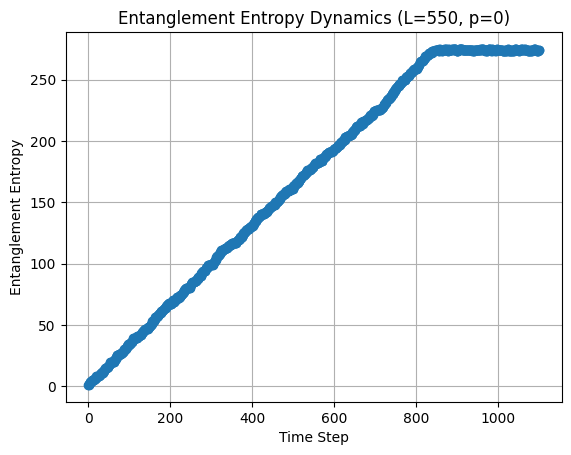

In [132]:
def entropy_over_time(L, T, p):
    """
    Simulates a random circuit with measurements and calculates the entanglement entropy after each layer.
    Returns a list of entropies at each time step.
    """
    sim = stim.TableauSimulator()
    entropies = []
    
    for t in range(T):
        parity = t % 2
        sim = one_layer_circuit(L, p, parity, sim)
        tableau = sim.current_inverse_tableau() ** -1
        _, _, z2x, z2z, _, _ = tableau.to_numpy()
        stabilizer_matrix = np.hstack([z2x.astype(np.uint8), z2z.astype(np.uint8)])
        
        entropy = calculate_entropy(stabilizer_matrix, n_cut=L//2)
        entropies.append(entropy)
        
    return entropies


#Plotting the entropy dynamics
import matplotlib.pyplot as plt 
L = 550
T = int(2 * L)
p = 0
entropies = entropy_over_time(L, T, p)
plt.plot(entropies, marker='o')
plt.title(f'Entanglement Entropy Dynamics (L={L}, p={p})')
plt.xlabel('Time Step')
plt.ylabel('Entanglement Entropy')
plt.grid()
plt.show()

Entropy for L=0: 0
Time taken for L=0: 0.0004 seconds
Entropy for L=50: 0
Time taken for L=50: 0.0557 seconds
Entropy for L=100: 0
Time taken for L=100: 0.1510 seconds
Entropy for L=150: 0
Time taken for L=150: 0.3580 seconds
Entropy for L=200: 0
Time taken for L=200: 0.6674 seconds
Entropy for L=250: 0
Time taken for L=250: 1.2452 seconds
Entropy for L=300: 1
Time taken for L=300: 1.7386 seconds
Entropy for L=350: 0
Time taken for L=350: 2.4028 seconds
Entropy for L=400: 1
Time taken for L=400: 3.4210 seconds
Entropy for L=450: 1
Time taken for L=450: 4.5315 seconds
Entropy for L=500: 0
Time taken for L=500: 5.8151 seconds
Entropy for L=550: 0
Time taken for L=550: 7.5379 seconds


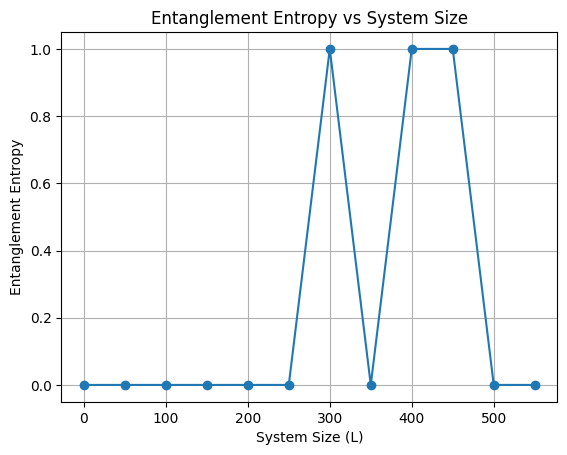

In [115]:
import matplotlib.pyplot as plt
def multilayer_circuit(L, T, p):
    """
    Generates a multi-layer circuit with random 2-qubit Clifford gates and measurements.
     Args:
    - L: Total number of qubits (must be even)
    - T: Number of layers
    - p: Probability of measuring each qubit

    Returns:
    - A binary stabilizer matrix representing the final state after T layers

    
    This function constructs the circuit layer by layer, applying the gates and measurements immediately after each layer.
    It does NOT build the entire circuit first and then execute it. The former saves memory and allows for intermediate state extraction if needed.
    """
    sim = stim.TableauSimulator()
    sim.set_num_qubits(L)

    for t in range(T):
        parity = t % 2
        one_layer_circuit(L, p, parity, sim)
    tableau = sim.current_inverse_tableau() ** -1 
    _, _, z2x, z2z, _, _ = tableau.to_numpy() 
    return np.hstack([z2x.astype(np.uint8), z2z.astype(np.uint8)])

max = 600
entropies = []
t = []
for L in range(0,max,50):
    t.append(time.time())
    entropy = calculate_entropy(multilayer_circuit(L, 2 * L, 0.5), n_cut=L//2)
    entropies.append(entropy)
    t.append(time.time())
    print(f"Entropy for L={L}: {entropy}")
    print(f"Time taken for L={L}: {t[-1] - t[-2]:.4f} seconds")

#plotting
plt.plot(range(0,max,50), entropies, marker='o')
plt.title('Entanglement Entropy vs System Size')
plt.xlabel('System Size (L)')
plt.ylabel('Entanglement Entropy')
plt.grid()
plt.show()